In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('C:/Users/cjmwo/meituan/train .csv')

In [6]:
df.head(10)

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2 years,2,...,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5 years,0,...,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8 years,0,...,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10+ years,1,...,16.0,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0
4,4,3000.0,3,12.99,101.07,C,C2,54.0,NaN,1,...,4.0,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0
5,5,11000.0,3,7.99,344.65,A,A5,51727.0,7 years,0,...,1.0,48.0,2.0,3.0,2.0,19.0,0.0,0.0,0.0,0.0
6,6,2050.0,3,7.69,63.95,A,A4,180083.0,9 years,0,...,11.0,3.0,10.0,18.0,3.0,12.0,0.0,0.0,0.0,3.0
7,7,11500.0,3,14.98,398.54,C,C3,214017.0,1 year,1,...,16.0,10.0,5.0,21.0,4.0,8.0,0.0,0.0,0.0,2.0
8,8,12000.0,3,12.99,404.27,C,C2,188.0,5 years,2,...,7.0,2.0,13.0,17.0,11.0,15.0,NaN,0.0,0.0,6.0
9,9,6500.0,3,10.99,212.78,B,B4,54.0,NaN,1,...,21.0,24.0,6.0,39.0,5.0,7.0,0.0,0.0,0.0,8.0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,532671.0,266335.000000,153769.016957,0.00,133167.50,266335.00,399502.50,532670.00
loanAmnt,532671.0,14413.209232,8705.182159,500.00,8000.00,12000.00,20000.00,40000.00
term,532671.0,3.482737,0.855827,3.00,3.00,3.00,3.00,5.00
interestRate,532671.0,13.233641,4.766336,5.31,9.75,12.74,15.99,30.99
installment,532671.0,437.830276,261.117772,15.69,248.52,375.12,580.22,1715.42
employmentTitle,532670.0,72064.757189,106575.147011,0.00,427.00,7820.00,117932.25,378350.00
homeOwnership,532671.0,0.614238,0.676215,0.00,0.00,1.00,1.00,5.00
annualIncome,532671.0,76079.046729,69141.292536,0.00,45500.00,65000.00,90000.00,10999200.00
verificationStatus,532671.0,1.008959,0.782541,0.00,0.00,1.00,2.00,2.00
isDefault,532670.0,0.199501,0.399625,0.00,0.00,0.00,0.00,1.00


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 查看分布
print(df['isDefault'].value_counts())

print('\n占比：')
print(df['isDefault'].value_counts(normalize=True)*100)

isDefault
0.0    426402
1.0    106268
Name: count, dtype: int64

占比：
isDefault
0.0    80.049937
1.0    19.950063
Name: proportion, dtype: float64


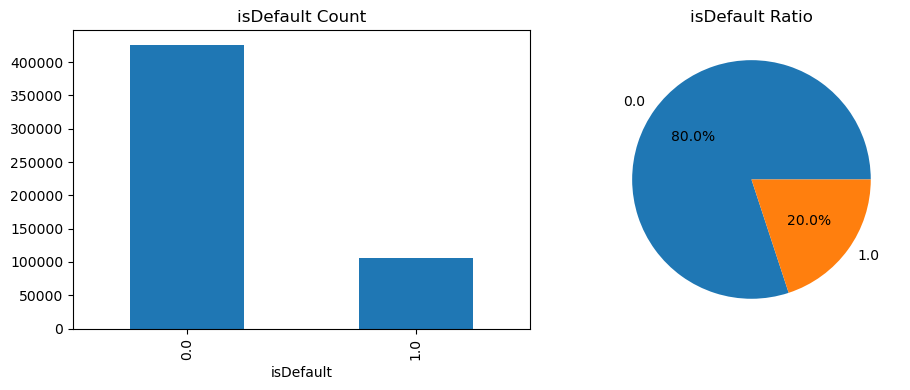

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df['isDefault'].value_counts().plot(
    kind='bar'
)
plt.title('isDefault Count')

plt.subplot(1,2,2)
df['isDefault'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('isDefault Ratio')

plt.tight_layout()
plt.show()

In [11]:
default_df = df[df['isDefault']==1]

print(default_df.shape)

(106268, 47)


In [14]:
cat_cols = [
    'grade',
    'subGrade',
    'homeOwnership',
    'verificationStatus',
    'purpose',
    'regionCode'
]

In [15]:
for col in cat_cols:

    print('\n')
    print('='*50)
    print(col)

    temp = (
        default_df[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .head(10)
    )

    print(temp)



grade
grade
C    32.17
D    22.72
B    19.24
E    13.43
F     5.42
A     5.34
G     1.68
Name: proportion, dtype: float64


subGrade
subGrade
C4    6.92
C5    6.57
C3    6.41
C2    6.14
C1    6.14
D1    5.28
B5    5.04
D2    4.94
B4    4.53
D3    4.51
Name: proportion, dtype: float64


homeOwnership
homeOwnership
1    46.12
0    42.63
2    11.20
3     0.02
5     0.02
4     0.00
Name: proportion, dtype: float64


verificationStatus
verificationStatus
1    40.81
2    37.08
0    22.11
Name: proportion, dtype: float64


purpose
purpose
0.0     61.42
4.0     18.73
5.0      6.05
2.0      5.71
3.0      2.08
1.0      1.69
9.0      1.25
10.0     0.82
8.0      0.79
7.0      0.67
Name: proportion, dtype: float64


regionCode
regionCode
8.0     14.30
13.0     8.91
14.0     8.15
21.0     7.64
30.0     3.81
0.0      3.52
19.0     3.49
2.0      3.45
3.0      3.00
7.0      2.95
Name: proportion, dtype: float64


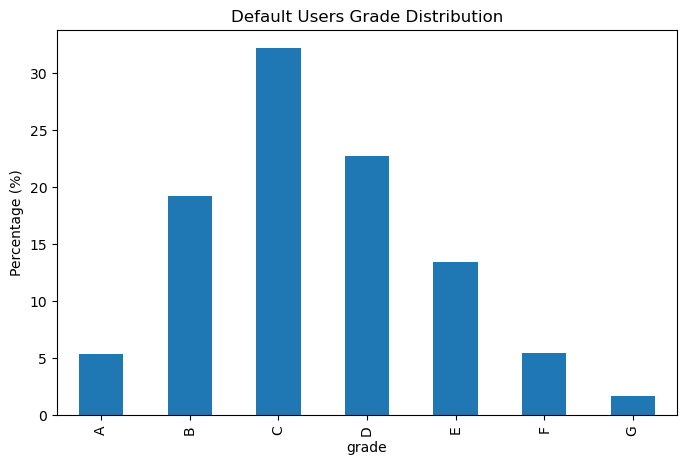

In [18]:
import seaborn as sns

plt.figure(figsize=(8,5))

(
default_df['grade']
.value_counts(normalize=True)
.mul(100)
.sort_index()
.plot(kind='bar')
)

plt.ylabel('Percentage (%)')
plt.title('Default Users Grade Distribution')
plt.show()

In [23]:
grade_default_rate = (
    df.groupby('grade')['isDefault']
      .mean()
      .sort_values(ascending=False)
)

print(grade_default_rate)

grade
G    0.495420
F    0.455567
E    0.384503
D    0.304796
C    0.225913
B    0.131449
A    0.060843
Name: isDefault, dtype: float64


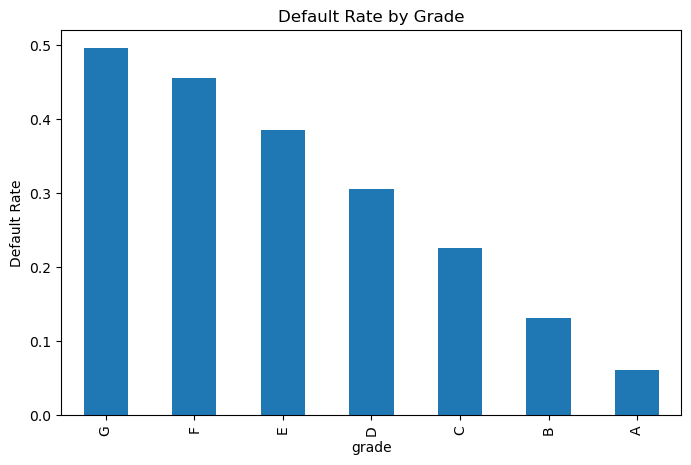

In [26]:
plt.figure(figsize=(8,5))

grade_default_rate.plot(
    kind='bar'
)

plt.ylabel('Default Rate')
plt.title('Default Rate by Grade')

plt.show()

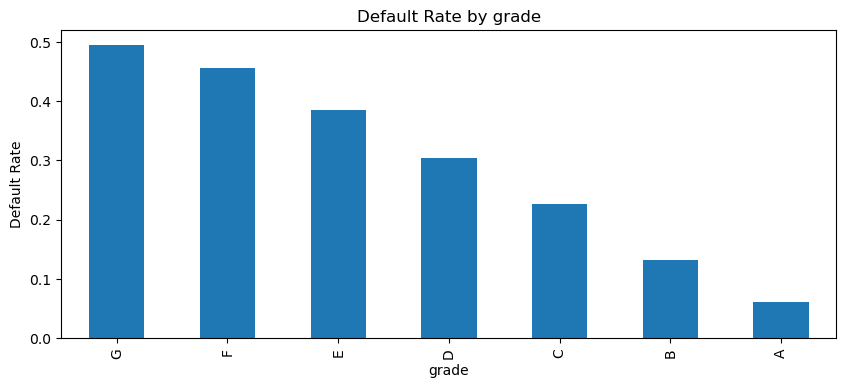

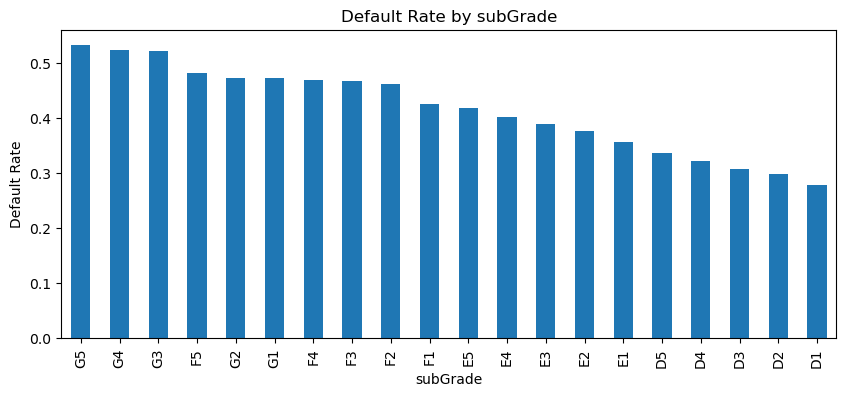

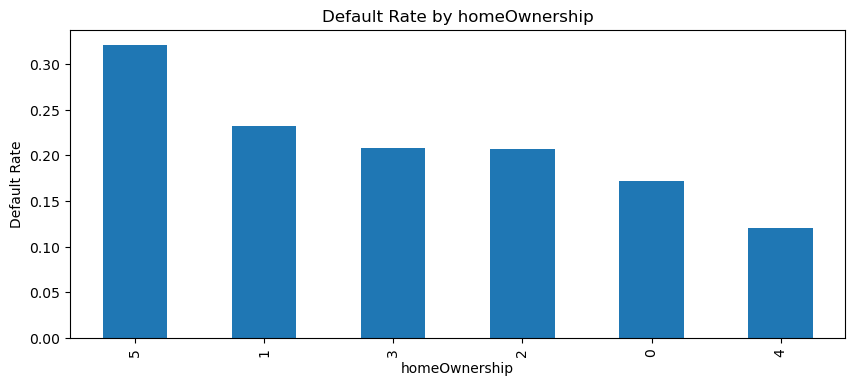

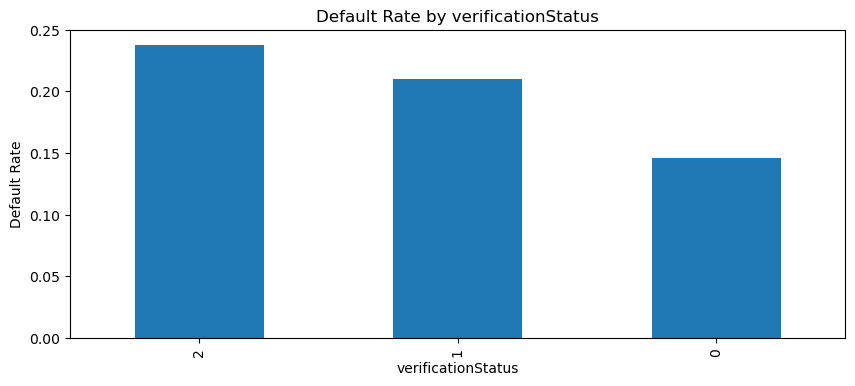

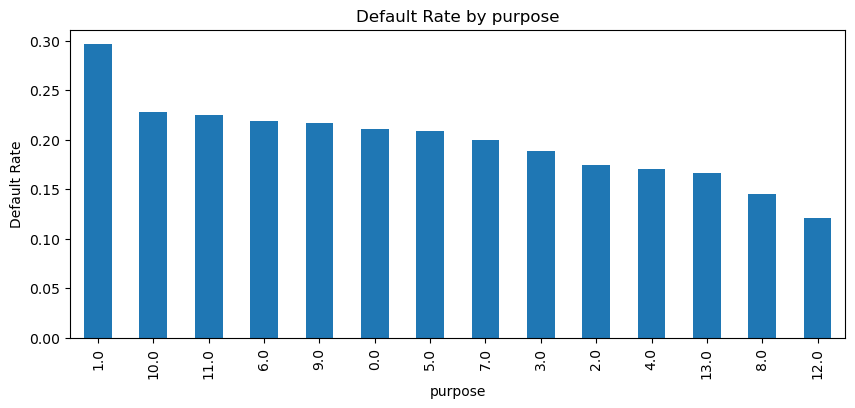

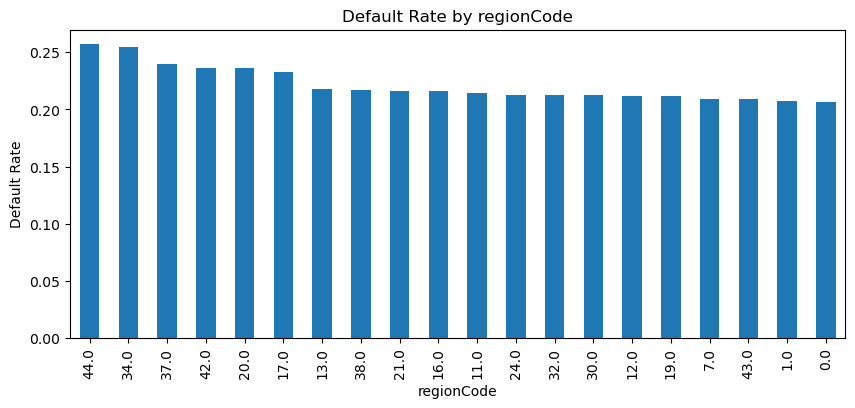

In [28]:
cat_cols = [
    'grade',
    'subGrade',
    'homeOwnership',
    'verificationStatus',
    'purpose',
    'regionCode'
]

for col in cat_cols:

    plt.figure(figsize=(10,4))

    (
        df.groupby(col)['isDefault']
        .mean()
        .sort_values(ascending=False)
        .head(20)
        .plot(kind='bar')
    )

    plt.title(f'Default Rate by {col}')
    plt.ylabel('Default Rate')

    plt.show()

In [29]:
default_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,106268.0,266106.840121,153961.406777,0.00,132299.2500,266209.50,399474.0000,532664.00
loanAmnt,106268.0,15542.573258,8788.039614,900.00,9000.0000,14300.00,20250.0000,40000.00
term,106268.0,3.784827,0.976581,3.00,3.0000,3.00,5.0000,5.00
interestRate,106268.0,15.719551,4.904105,5.31,12.2900,15.05,18.5500,30.99
installment,106268.0,464.457144,261.804720,22.79,275.8175,402.57,602.7225,1715.42
employmentTitle,106268.0,65419.350011,103096.302000,0.00,307.0000,6076.00,94467.5000,378344.00
homeOwnership,106268.0,0.686999,0.666576,0.00,0.0000,1.00,1.0000,5.00
annualIncome,106268.0,70131.954894,63025.650866,0.00,43000.0000,60000.00,85000.0000,8706582.00
verificationStatus,106268.0,1.149706,0.754679,0.00,1.0000,1.00,2.0000,2.00
isDefault,106268.0,1.000000,0.000000,1.00,1.0000,1.00,1.0000,1.00


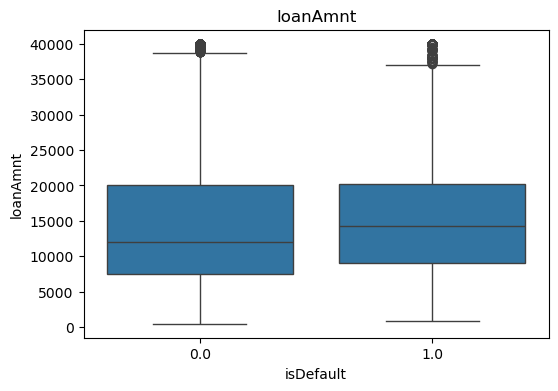

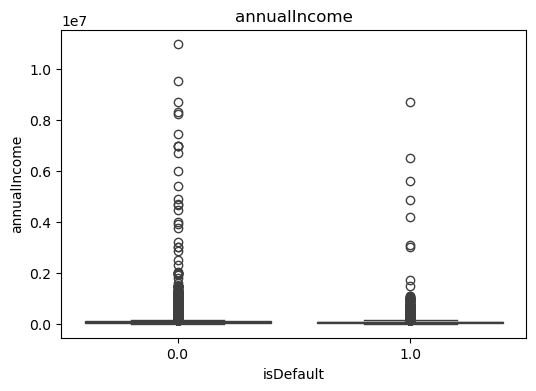

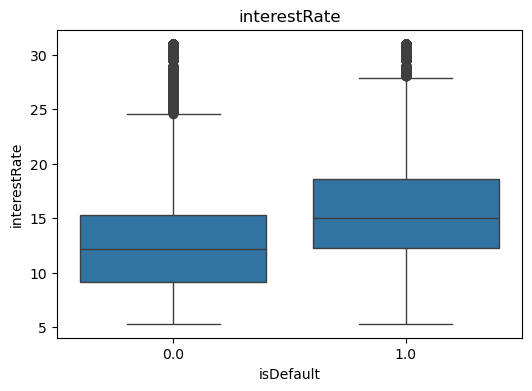

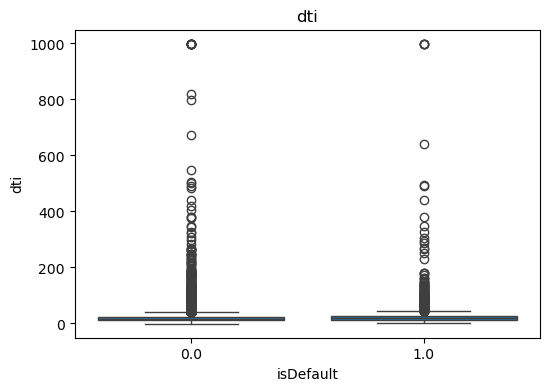

In [30]:
num_cols = [
    'loanAmnt',
    'annualIncome',
    'interestRate',
    'dti'
]

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x='isDefault',
        y=col,
        data=df
    )

    plt.title(col)

    plt.show()

In [33]:
df = df.dropna(subset=['isDefault'])

print(df['isDefault'].isnull().sum())

0


In [38]:
import pandas as pd
import scorecardpy as sc

# 重新导入原始数据
df = pd.read_csv('train .csv')

# 清理列名空格
df.columns = df.columns.str.strip()

target = 'isDefault'

# 检查
print(target in df.columns)
print(df[target].value_counts(dropna=False))

# 删除target缺失
df = df.dropna(subset=[target])
df[target] = df[target].astype(int)

# 删除无效变量
df_iv = df.drop(columns=['id', 'policyCode'], errors='ignore')

# 再确认
print(target in df_iv.columns)

# 计算IV
bins = sc.woebin(
    df_iv,
    y=target,
    method='chimerge'
)

True
isDefault
0.0    426402
1.0    106268
NaN         1
Name: count, dtype: int64
True
[INFO] creating woe binning ...


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import scorecardpy as sc
import matplotlib.pyplot as plt



# 提取IV
iv_list = []

for col in bins.keys():

    iv_list.append([
        col,
        bins[col]['total_iv'].iloc[0]
    ])

iv_df = pd.DataFrame(
    iv_list,
    columns=['Variable','IV']
)

iv_df = iv_df.sort_values(
    'IV',
    ascending=False
)

print(iv_df)

# IV柱状图
plt.figure(figsize=(12,8))

iv_df.head(20).sort_values(
    'IV'
).plot(
    x='Variable',
    y='IV',
    kind='barh'
)

plt.title('Top 20 IV Variables')
plt.xlabel('IV')

plt.show()

In [36]:
df['isDefault']

0         1.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
532665    0.0
532666    0.0
532667    0.0
532668    0.0
532669    0.0
Name: isDefault, Length: 532670, dtype: float64

In [38]:
# 去掉列名前后空格
df.columns = df.columns.str.strip()

# 查看所有列名
print(df.columns.tolist())

# 模糊查找 default 相关列
print([col for col in df.columns if 'default' in col.lower() or 'defalut' in col.lower()])

['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership', 'annualIncome', 'verificationStatus', 'issueDate', 'isDefault', 'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec', 'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc', 'initialListStatus', 'applicationType', 'earliesCreditLine', 'title', 'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14']
['isDefault']


In [88]:
drop_cols = [
    'n1',
    'purpose',
    'n7',
    'employmentLength',
    'employmentTitle',
    'n10',
    'n0',
    'n5',
    'n4',
    'n13',
    'n6',
    'n8',
    'pubRec',
    'n12',
    'regionCode',
    'pubRecBankruptcies',
    'openAcc',
    'revolBal',
    'delinquency_2years',
    'totalAcc',
    'postCode',
    'initialListStatus',
    'n11',
    'applicationType'
    
]

df = df.drop(columns=drop_cols)

print("保留变量数量：", len(df_iv_selected.columns))
print("\n保留变量：")
print(df_iv_selected.columns.tolist())

保留变量数量： 23

保留变量：
['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade', 'homeOwnership', 'annualIncome', 'verificationStatus', 'issueDate', 'isDefault', 'dti', 'ficoRangeLow', 'ficoRangeHigh', 'revolUtil', 'earliesCreditLine', 'title', 'policyCode', 'n2', 'n3', 'n9', 'n14']


In [90]:
import pandas as pd

# 转日期格式
df['issueDate'] = pd.to_datetime(df['issueDate'])

# 提取年月
df['issueMonth'] = df['issueDate'].dt.to_period('M')

df[['issueDate','issueMonth']].head()

,issueDate,issueMonth
0,2014-07-01,2014-07
1,2012-08-01,2012-08
2,2015-10-01,2015-10
3,2015-08-01,2015-08
4,2016-03-01,2016-03


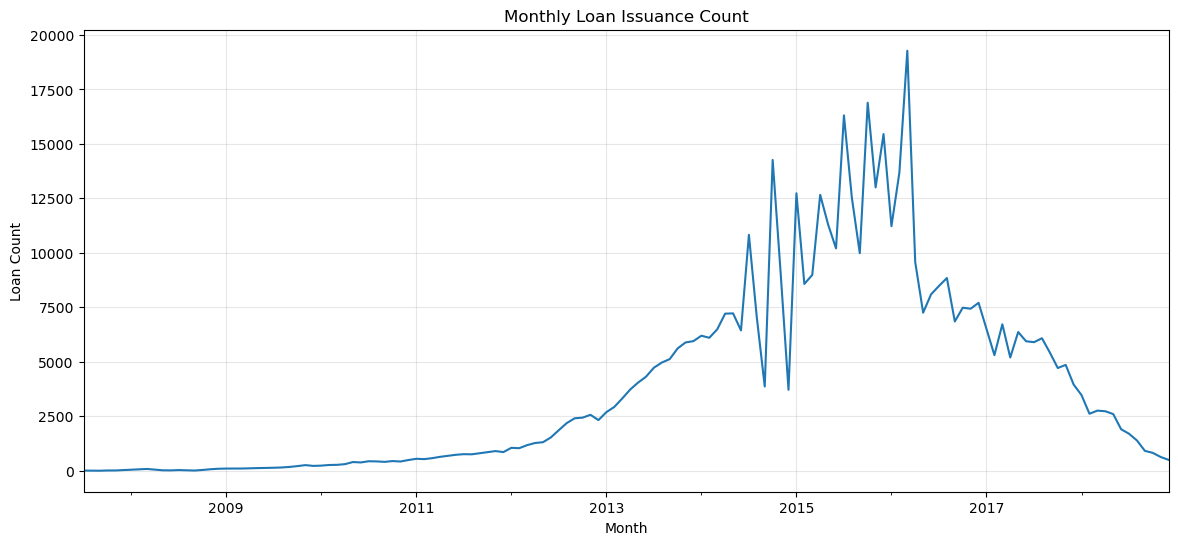

In [92]:
import matplotlib.pyplot as plt

monthly_count = (
    df.groupby('issueMonth')
      .size()
)

plt.figure(figsize=(14,6))

monthly_count.plot()

plt.title('Monthly Loan Issuance Count')
plt.xlabel('Month')
plt.ylabel('Loan Count')

plt.grid(alpha=0.3)

plt.show()

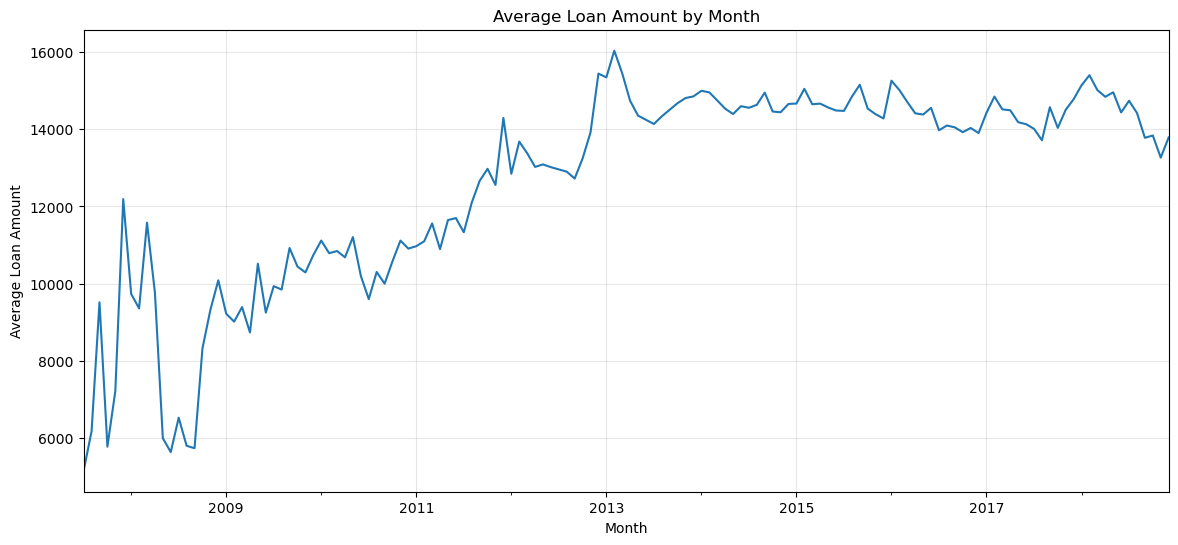

In [94]:
monthly_loanamt = (
    df.groupby('issueMonth')['loanAmnt']
      .mean()
)

plt.figure(figsize=(14,6))

monthly_loanamt.plot()

plt.title('Average Loan Amount by Month')
plt.xlabel('Month')
plt.ylabel('Average Loan Amount')

plt.grid(alpha=0.3)

plt.show()

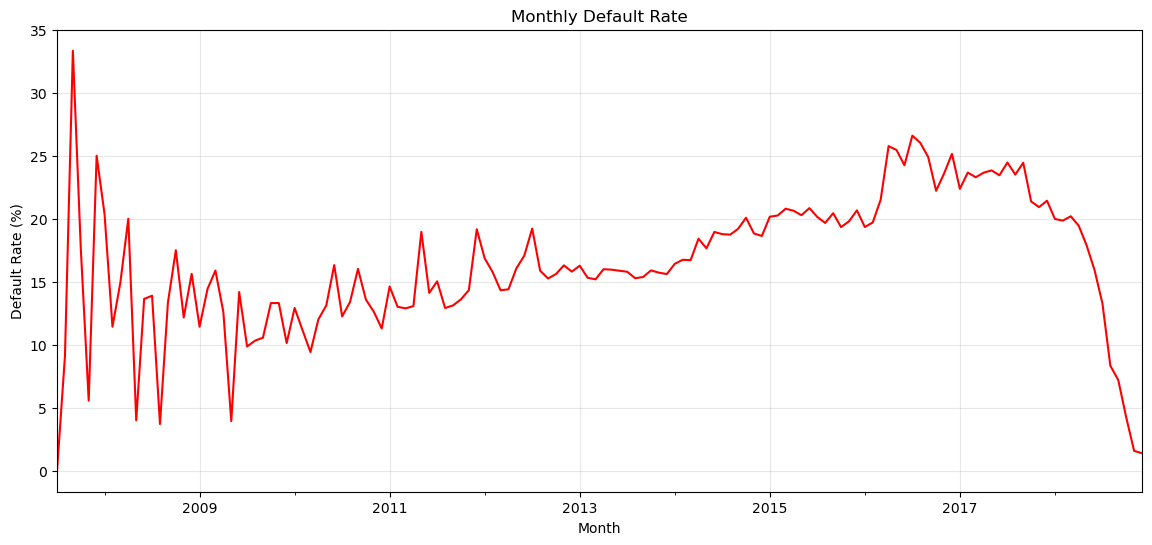

In [96]:
monthly_default_rate = (
    df.groupby('issueMonth')['isDefault']
      .mean()
      *100
)

plt.figure(figsize=(14,6))

monthly_default_rate.plot(
    color='red'
)

plt.title('Monthly Default Rate')
plt.xlabel('Month')
plt.ylabel('Default Rate (%)')

plt.grid(alpha=0.3)

plt.show()

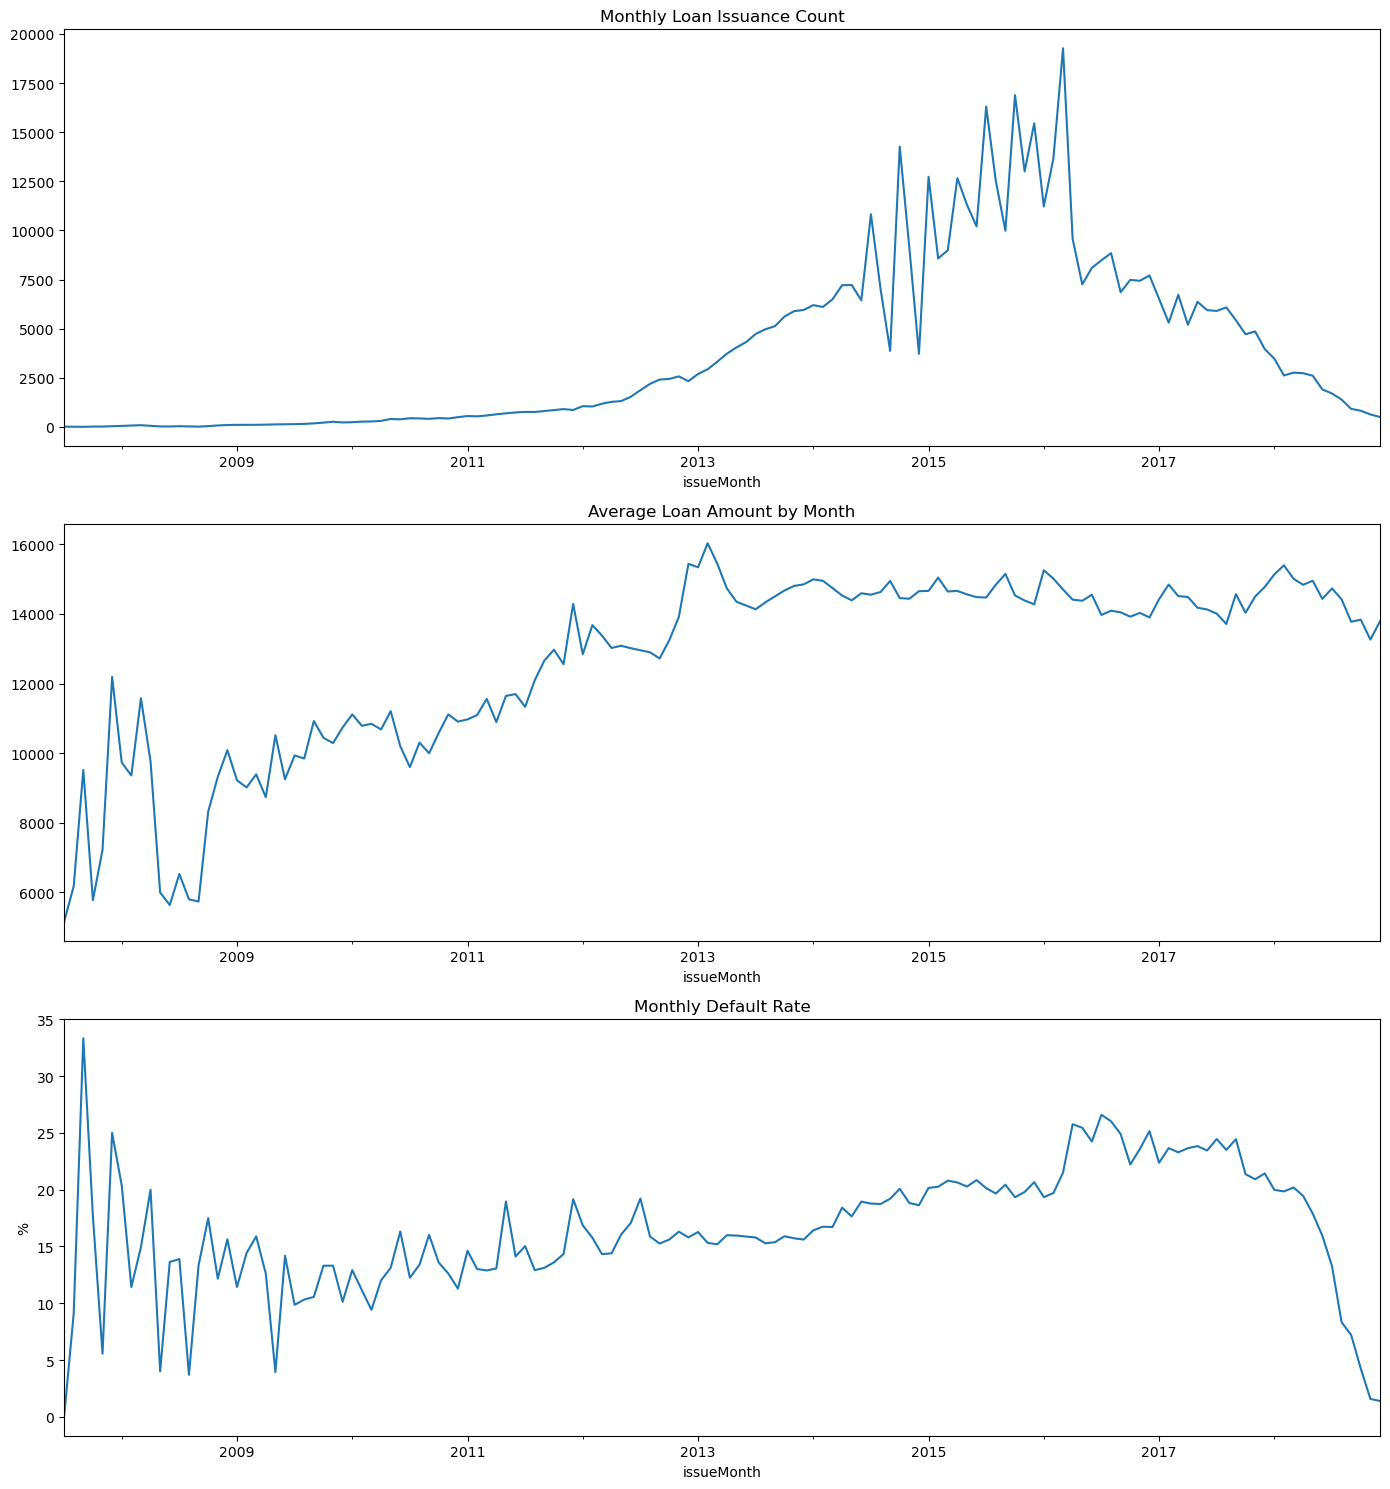

In [98]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,15)
)

# 发放数量
(
df.groupby('issueMonth')
  .size()
).plot(
    ax=axes[0]
)

axes[0].set_title(
    'Monthly Loan Issuance Count'
)

# 平均贷款金额
(
df.groupby('issueMonth')['loanAmnt']
  .mean()
).plot(
    ax=axes[1]
)

axes[1].set_title(
    'Average Loan Amount by Month'
)

# 违约率
(
df.groupby('issueMonth')['isDefault']
  .mean()*100
).plot(
    ax=axes[2]
)

axes[2].set_title(
    'Monthly Default Rate'
)

axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()

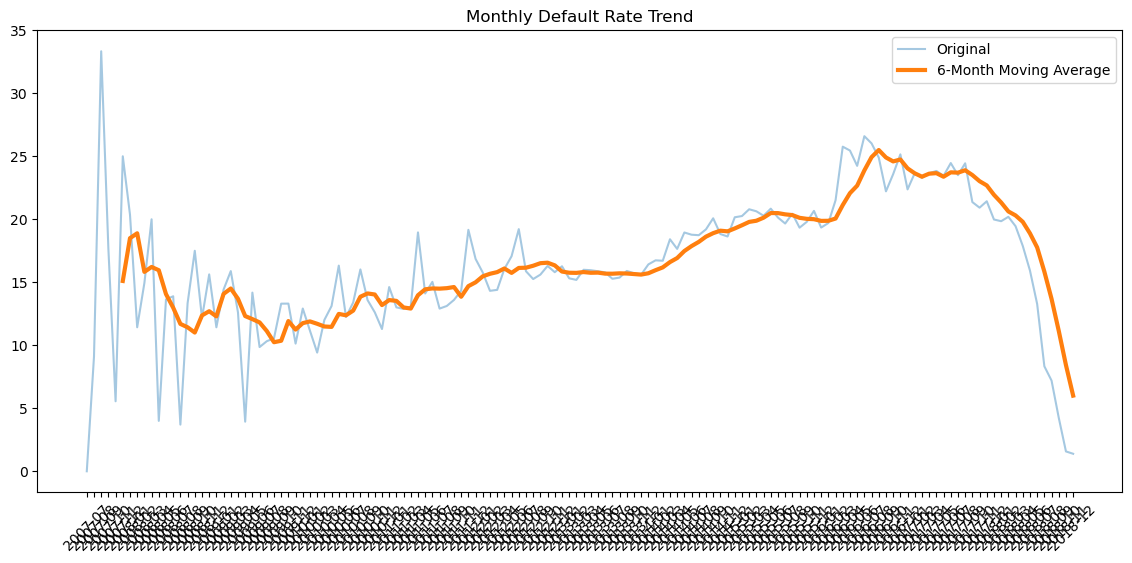

In [100]:
monthly_default_rate = (
    df.groupby('issueMonth')['isDefault']
      .mean()
      *100
)

monthly_default_rate = monthly_default_rate.astype(float)

rolling_rate = (
    monthly_default_rate
    .rolling(6)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_default_rate.index.astype(str),
    monthly_default_rate,
    alpha=0.4,
    label='Original'
)

plt.plot(
    monthly_default_rate.index.astype(str),
    rolling_rate,
    linewidth=3,
    label='6-Month Moving Average'
)

plt.xticks(rotation=45)

plt.legend()

plt.title(
    'Monthly Default Rate Trend'
)

plt.show()

In [102]:
monthly_count = (
    df.groupby('issueMonth')
      .size()
      .reset_index(name='count')
)

print(monthly_count.tail(24))

    issueMonth  count
114    2017-01   6517
115    2017-02   5308
116    2017-03   6724
117    2017-04   5200
118    2017-05   6368
119    2017-06   5945
120    2017-07   5903
121    2017-08   6084
122    2017-09   5429
123    2017-10   4718
124    2017-11   4861
125    2017-12   3962
126    2018-01   3473
127    2018-02   2620
128    2018-03   2763
129    2018-04   2735
130    2018-05   2605
131    2018-06   1908
132    2018-07   1702
133    2018-08   1392
134    2018-09    917
135    2018-10    824
136    2018-11    635
137    2018-12    504


In [104]:
monthly_default = (
    df.groupby('issueMonth')['isDefault']
      .mean()
      .mul(100)
      .reset_index(name='default_rate')
)

print(monthly_default.tail(24))

    issueMonth  default_rate
114    2017-01     22.372257
115    2017-02     23.662396
116    2017-03     23.289709
117    2017-04     23.653846
118    2017-05     23.837940
119    2017-06     23.448276
120    2017-07     24.462138
121    2017-08     23.504274
122    2017-09     24.442807
123    2017-10     21.364985
124    2017-11     20.921621
125    2017-12     21.428571
126    2018-01     19.982724
127    2018-02     19.847328
128    2018-03     20.195440
129    2018-04     19.451554
130    2018-05     17.888676
131    2018-06     15.932914
132    2018-07     13.278496
133    2018-08      8.333333
134    2018-09      7.197383
135    2018-10      4.247573
136    2018-11      1.574803
137    2018-12      1.388889


In [106]:
monthly_default_rate = (
    df.groupby('issueMonth')['isDefault']
      .mean()*100
)

print(monthly_default_rate.tail(36))

issueMonth
2016-01    19.342480
2016-02    19.703281
2016-03    21.510844
2016-04    25.762322
2016-05    25.454796
2016-06    24.240553
2016-07    26.594365
2016-08    26.023061
2016-09    24.897840
2016-10    22.217769
2016-11    23.581608
2016-12    25.152419
2017-01    22.372257
2017-02    23.662396
2017-03    23.289709
2017-04    23.653846
2017-05    23.837940
2017-06    23.448276
2017-07    24.462138
2017-08    23.504274
2017-09    24.442807
2017-10    21.364985
2017-11    20.921621
2017-12    21.428571
2018-01    19.982724
2018-02    19.847328
2018-03    20.195440
2018-04    19.451554
2018-05    17.888676
2018-06    15.932914
2018-07    13.278496
2018-08     8.333333
2018-09     7.197383
2018-10     4.247573
2018-11     1.574803
2018-12     1.388889
Freq: M, Name: isDefault, dtype: float64


In [108]:
df['issueDate'] = pd.to_datetime(df['issueDate'])

df_clean = df[
    df['issueDate'] < '2018-07-01'
].copy()

print("原始样本:", df.shape)
print("删除右删失后:", df_clean.shape)

原始样本: (532515, 26)
删除右删失后: (526541, 26)


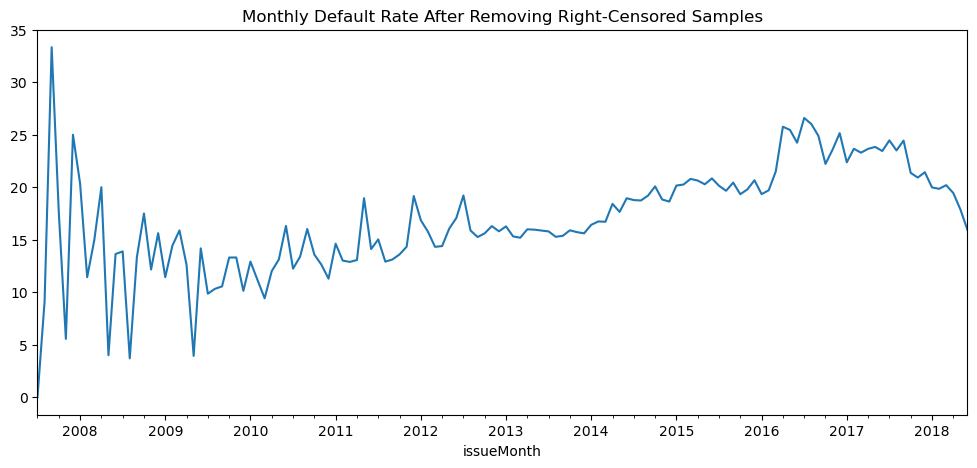

In [110]:
monthly_default_rate = (
    df_clean.groupby('issueMonth')['isDefault']
            .mean()*100
)

monthly_default_rate.plot(
    figsize=(12,5)
)

plt.title(
    'Monthly Default Rate After Removing Right-Censored Samples'
)

plt.show()

In [112]:
import numpy as np

df['annualIncome_log'] = np.log1p(df['annualIncome'])

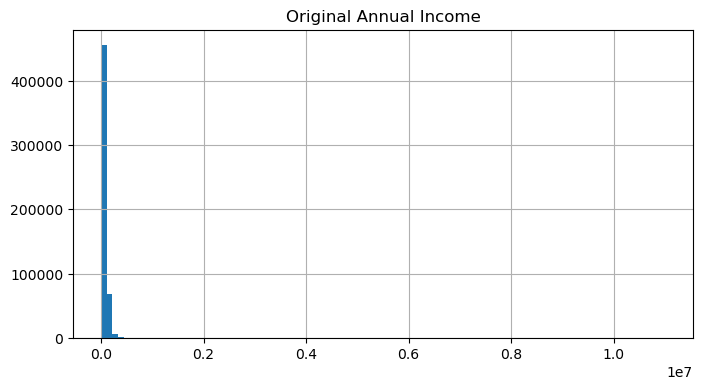

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

df['annualIncome'].hist(
    bins=100
)

plt.title('Original Annual Income')

plt.show()

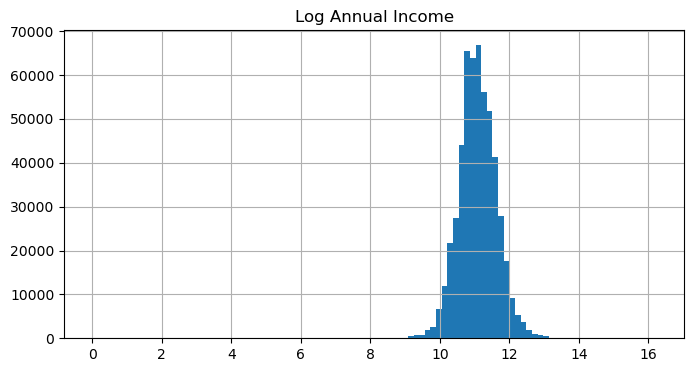

In [66]:
plt.figure(figsize=(8,4))

df['annualIncome_log'].hist(
    bins=100
)

plt.title('Log Annual Income')

plt.show()

In [116]:
print(df['dti'].describe())

print("\ndti<0:")
print((df['dti']<0).sum())

print("\ndti==999:")
print((df['dti']==999).sum())

print("\ndti>100:")
print((df['dti']>100).sum())

print("\n分位数：")
print(
    df['dti'].quantile([
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ])
)

count    532515.000000
mean         18.202945
std           8.688853
min           0.000000
25%          11.790000
50%          17.620000
75%          24.070000
max          66.158600
Name: dti, dtype: float64

dti<0:
0

dti==999:
0

dti>100:
0

分位数：
0.900    29.81000
0.950    33.00000
0.990    38.44000
0.995    40.03000
0.999    66.13362
Name: dti, dtype: float64


In [118]:
import numpy as np

# 删除负值
df = df[df['dti'] >= 0]

# 999视为缺失
df.loc[df['dti'] == 999, 'dti'] = np.nan

# 中位数填补
df['dti'] = df['dti'].fillna(
    df['dti'].median()
)

# 99.9%截尾
upper = df['dti'].quantile(0.999)

df['dti'] = df['dti'].clip(
    upper=upper
)

print(df['dti'].describe())

count    532515.000000
mean         18.202920
std           8.688715
min           0.000000
25%          11.790000
50%          17.620000
75%          24.070000
max          66.133620
Name: dti, dtype: float64


In [120]:
print(df['revolUtil'].describe())

count    532164.000000
mean         51.738444
std          24.474177
min           0.000000
25%          33.400000
50%          52.100000
75%          70.700000
max         102.300000
Name: revolUtil, dtype: float64


In [122]:
print(
    df['revolUtil'].quantile([
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ])
)

0.900     84.9
0.950     91.4
0.990     98.2
0.995     99.5
0.999    102.3
Name: revolUtil, dtype: float64


In [124]:
print("revolUtil>100:")
print((df['revolUtil']>100).sum())

print("revolUtil>120:")
print((df['revolUtil']>120).sum())

print("revolUtil>150:")
print((df['revolUtil']>150).sum())

revolUtil>100:
1771
revolUtil>120:
0
revolUtil>150:
0


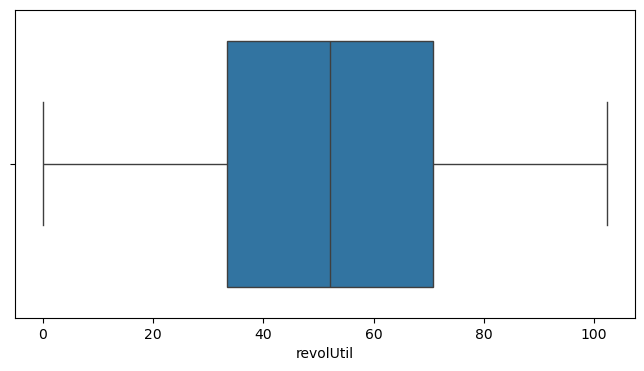

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['revolUtil']
)

plt.show()

In [128]:
import numpy as np

df['revol_flag'] = np.where(
    df['revolUtil'] > 100,
    'High',
    'Normal'
)

print(
    df.groupby('revol_flag')['isDefault']
      .agg(['count','mean'])
)

             count      mean
revol_flag                  
High          1771  0.263693
Normal      530744  0.199288


In [130]:
upper = df['revolUtil'].quantile(0.999)

df['revolUtil'] = df['revolUtil'].clip(
    upper=upper
)

In [132]:
# 排除目标变量和日期
feature_cols = [
    col for col in df.columns
    if col not in ['isDefault','issueDate']
]

num_cols = []
cat_cols = []

for col in feature_cols:

    if df[col].nunique() > 25:
        num_cols.append(col)
    else:
        cat_cols.append(col)

print("数值型变量：")
print(num_cols)

print("\n分类型变量：")
print(cat_cols)

数值型变量：
['id', 'loanAmnt', 'interestRate', 'installment', 'subGrade', 'annualIncome', 'dti', 'ficoRangeLow', 'ficoRangeHigh', 'revolUtil', 'earliesCreditLine', 'title', 'n2', 'n3', 'n9', 'n14', 'issueMonth', 'annualIncome_log']

分类型变量：
['term', 'grade', 'homeOwnership', 'verificationStatus', 'policyCode', 'revol_flag']


In [134]:
print("变量数量：", len(df.columns))

变量数量： 26


In [146]:
df = df.drop(
    columns=['annualIncome', 'policyCode', 'revolUtil','id'],
    errors='ignore'
)
   

In [148]:
df.shape

(532515, 22)

In [150]:
print(df.columns.tolist())

['loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade', 'homeOwnership', 'verificationStatus', 'issueDate', 'isDefault', 'dti', 'ficoRangeLow', 'ficoRangeHigh', 'earliesCreditLine', 'title', 'n2', 'n3', 'n9', 'n14', 'issueMonth', 'annualIncome_log', 'revol_flag']


In [152]:
print(df.isnull().sum())

loanAmnt                  0
term                      0
interestRate              0
installment               0
grade                     0
subGrade                  0
homeOwnership             0
verificationStatus        0
issueDate                 0
isDefault                 0
dti                       0
ficoRangeLow              0
ficoRangeHigh             0
earliesCreditLine         0
title                     1
n2                    26949
n3                    26949
n9                    26949
n14                   26949
issueMonth                0
annualIncome_log          0
revol_flag                0
dtype: int64


In [154]:
# 删除title缺失
df = df.dropna(subset=['title'])

# n变量均值填补
n_cols = ['n2','n3','n9','n14']

df[n_cols] = df[n_cols].fillna(
    df[n_cols].mean()
)

# 查看缺失值
print(df[['title','n2','n3','n9','n14']].isnull().sum())

# 查看数据维度
print("当前数据维度：", df.shape)

title    0
n2       0
n3       0
n9       0
n14      0
dtype: int64
当前数据维度： (532514, 22)


In [156]:
sigma_cols = [
    'loanAmnt',
    'interestRate',
    'installment',
    'ficoRangeLow',
    'ficoRangeHigh',
    'n2',
    'n3',
    'n9',
    'n14'
]

for col in sigma_cols:

    mean = df[col].mean()
    std = df[col].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    outlier_num = (
        ((df[col] < lower) |
         (df[col] > upper))
    ).sum()

    print(
        f"{col}: {outlier_num}"
    )

loanAmnt: 0
interestRate: 3803
installment: 5282
ficoRangeLow: 7776
ficoRangeHigh: 7776
n2: 7224
n3: 7224
n9: 8982
n14: 7378


In [158]:
sigma_cols = [
    'n2',
    'n3',
    'n9',
    'n14'
]

for col in sigma_cols:

    mean = df[col].mean()
    std = df[col].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    print(
        col,
        ((df[col] < lower) |
         (df[col] > upper)).sum()
    )

n2 7224
n3 7224
n9 8982
n14 7378


In [160]:
sigma_cols = [
    'n2',
    'n3',
    'n9',
    'n14'
]

for col in sigma_cols:

    mean = df[col].mean()
    std = df[col].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    df = df[
        (df[col] >= lower)
        &
        (df[col] <= upper)
    ]

print("处理后数据维度：", df.shape)

处理后数据维度： (511886, 22)


In [164]:
df.head(20).T

,0,1,2,3,4,5,6,7,8,10,11,13,14,15,16,17,18,19,20,21
loanAmnt,35000.0,18000.0,12000.0,11000.0,3000.0,11000.0,2050.0,11500.0,12000.0,5600.0,5000.0,24000.0,16000.0,6000.0,10375.0,5500.0,6000.0,20000.0,15500.0,3000.0
term,5,5,5,3,3,3,3,3,3,3,3,3,3,3,5,3,3,5,5,3
interestRate,19.52,18.49,16.99,7.26,12.99,7.99,7.69,14.98,12.99,13.67,27.27,9.99,7.91,10.49,15.61,10.99,21.0,21.0,15.99,12.29
installment,917.97,461.9,298.17,340.96,101.07,344.65,63.95,398.54,404.27,190.5,204.86,774.3,500.72,194.99,250.16,180.04,226.06,541.07,376.85,100.06
grade,E,D,D,A,C,A,A,C,C,B,E,B,A,B,D,B,E,E,C,C
subGrade,E2,D2,D3,A4,C2,A5,A4,C3,C2,B5,E5,B3,A5,B2,D1,B4,E2,E1,C5,C1
homeOwnership,2,0,0,1,1,0,0,1,2,1,0,0,1,0,0,1,1,1,0,1
verificationStatus,2,2,2,1,2,2,0,2,1,0,0,1,0,1,0,1,0,2,0,2
issueDate,2014-07-01 00:00:00,2012-08-01 00:00:00,2015-10-01 00:00:00,2015-08-01 00:00:00,2016-03-01 00:00:00,2017-04-01 00:00:00,2014-10-01 00:00:00,2014-01-01 00:00:00,2016-05-01 00:00:00,2013-11-01 00:00:00,2018-12-01 00:00:00,2015-08-01 00:00:00,2016-01-01 00:00:00,2017-02-01 00:00:00,2014-05-01 00:00:00,2015-05-01 00:00:00,2012-12-01 00:00:00,2013-12-01 00:00:00,2016-12-01 00:00:00,2015-04-01 00:00:00
isDefault,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [166]:
from sklearn.preprocessing import LabelEncoder

# 创建编码器
le = LabelEncoder()

# 需要编码的列
encode_cols = [
    'grade',
    'subGrade',
    'revol_flag'
]

# 编码
for col in encode_cols:
    
    df[col] = le.fit_transform(df[col])
    
    print(f"\n{col} 编码映射：")
    
    mapping = dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
    
    print(mapping)

# 查看结果
print(df[
    ['grade','subGrade','revol_flag']
].head())


grade 编码映射：
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}

subGrade 编码映射：
{'A1': 0, 'A2': 1, 'A3': 2, 'A4': 3, 'A5': 4, 'B1': 5, 'B2': 6, 'B3': 7, 'B4': 8, 'B5': 9, 'C1': 10, 'C2': 11, 'C3': 12, 'C4': 13, 'C5': 14, 'D1': 15, 'D2': 16, 'D3': 17, 'D4': 18, 'D5': 19, 'E1': 20, 'E2': 21, 'E3': 22, 'E4': 23, 'E5': 24, 'F1': 25, 'F2': 26, 'F3': 27, 'F4': 28, 'F5': 29, 'G1': 30, 'G2': 31, 'G3': 32, 'G4': 33, 'G5': 34}

revol_flag 编码映射：
{'High': 0, 'Normal': 1}
   grade  subGrade  revol_flag
0      4        21           1
1      3        16           1
2      3        17           1
3      0         3           1
4      2        11           1


In [176]:
import pandas as pd

# =========================
# 1. 查看原始数据
# =========================
print("转换前：")
print(df['issueMonth'].head())

# =========================
# 2. 转换为时间格式
# =========================
df['issueMonth'] = df['issueMonth'].dt.to_timestamp()

# =========================
# 3. 设置基准日期
# =========================
startdate = pd.to_datetime(
    '2007-06-01'
)

# =========================
# 4. 构造时间差特征
# =========================
df['issueDateDT'] = (
    df['issueMonth']
    - startdate
).dt.days

# =========================
# 5. 查看转换结果
# =========================
print("\n转换后：")

print(
    df[
        [
            'issueMonth',
            'issueDateDT'
        ]
    ].head(10)
)

# =========================
# 6. 查看统计情况
# =========================
print("\nissueDateDT统计信息：")

print(
    df['issueDateDT']
    .describe()
)

# =========================
# 7. 查看最早和最晚日期
# =========================
print("\n最早日期：")
print(df['issueMonth'].min())

print("\n最晚日期：")
print(df['issueMonth'].max())

转换前：
0    2014-07
1    2012-08
2    2015-10
3    2015-08
4    2016-03
Name: issueMonth, dtype: period[M]

转换后：
   issueMonth  issueDateDT
0  2014-07-01         2587
1  2012-08-01         1888
2  2015-10-01         3044
3  2015-08-01         2983
4  2016-03-01         3196
5  2017-04-01         3592
6  2014-10-01         2679
7  2014-01-01         2406
8  2016-05-01         3257
10 2013-11-01         2345

issueDateDT统计信息：
count    511886.000000
mean       2920.305121
std         595.434059
min          30.000000
25%        2587.000000
50%        2983.000000
75%        3318.000000
max        4201.000000
Name: issueDateDT, dtype: float64

最早日期：
2007-07-01 00:00:00

最晚日期：
2018-12-01 00:00:00


In [174]:
print(df['issueMonth'].dtype)

period[M]


In [182]:
# 提取贷款年份
df['issueYear'] = df['issueMonth'].dt.year

# 提取最早信用记录年份
df['earliesCreditLine_year'] = (
    df['earliesCreditLine']
      .str.extract(r'(\d{4})')
      .astype(int)
)

# 构造信用历史长度
df['creditAge'] = (
    df['issueYear']
    - df['earliesCreditLine_year']
)

print(
    df[
        ['issueYear',
         'earliesCreditLine_year',
         'creditAge']
    ].head()
)

   issueYear  earliesCreditLine_year  creditAge
0       2014                    2001         13
1       2012                    2002         10
2       2015                    2006          9
3       2015                    1999         16
4       2016                    1977         39


In [184]:
df.head(20).T

,0,1,2,3,4,5,6,7,8,10,11,13,14,15,16,17,18,19,20,21
loanAmnt,35000.0,18000.0,12000.0,11000.0,3000.0,11000.0,2050.0,11500.0,12000.0,5600.0,5000.0,24000.0,16000.0,6000.0,10375.0,5500.0,6000.0,20000.0,15500.0,3000.0
term,5,5,5,3,3,3,3,3,3,3,3,3,3,3,5,3,3,5,5,3
interestRate,19.52,18.49,16.99,7.26,12.99,7.99,7.69,14.98,12.99,13.67,27.27,9.99,7.91,10.49,15.61,10.99,21.0,21.0,15.99,12.29
installment,917.97,461.9,298.17,340.96,101.07,344.65,63.95,398.54,404.27,190.5,204.86,774.3,500.72,194.99,250.16,180.04,226.06,541.07,376.85,100.06
grade,4,3,3,0,2,0,0,2,2,1,4,1,0,1,3,1,4,4,2,2
subGrade,21,16,17,3,11,4,3,12,11,9,24,7,4,6,15,8,21,20,14,10
homeOwnership,2,0,0,1,1,0,0,1,2,1,0,0,1,0,0,1,1,1,0,1
verificationStatus,2,2,2,1,2,2,0,2,1,0,0,1,0,1,0,1,0,2,0,2
issueDate,2014-07-01 00:00:00,2012-08-01 00:00:00,2015-10-01 00:00:00,2015-08-01 00:00:00,2016-03-01 00:00:00,2017-04-01 00:00:00,2014-10-01 00:00:00,2014-01-01 00:00:00,2016-05-01 00:00:00,2013-11-01 00:00:00,2018-12-01 00:00:00,2015-08-01 00:00:00,2016-01-01 00:00:00,2017-02-01 00:00:00,2014-05-01 00:00:00,2015-05-01 00:00:00,2012-12-01 00:00:00,2013-12-01 00:00:00,2016-12-01 00:00:00,2015-04-01 00:00:00
isDefault,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [186]:
# 删除时间相关变量

df = df.drop(
    columns=[
        'issueDate',
        'issueMonth',
        'earliesCreditLine',
        'issueYear',
        'earliesCreditLine_year'
    ],
    errors='ignore'
)

# 查看删除后数据维度
print("数据维度：", df.shape)

# 查看所有变量
print("\n当前变量：")
print(df.columns.tolist())

# 查看前5行数据
print("\n数据预览：")
print(df.head())

数据维度： (511886, 21)

当前变量：
['loanAmnt', 'term', 'interestRate', 'installment', 'grade', 'subGrade', 'homeOwnership', 'verificationStatus', 'isDefault', 'dti', 'ficoRangeLow', 'ficoRangeHigh', 'title', 'n2', 'n3', 'n9', 'n14', 'annualIncome_log', 'revol_flag', 'issueDateDT', 'creditAge']

数据预览：
   loanAmnt  term  interestRate  installment  grade  subGrade  homeOwnership  \
0   35000.0     5         19.52       917.97      4        21              2   
1   18000.0     5         18.49       461.90      3        16              0   
2   12000.0     5         16.99       298.17      3        17              0   
3   11000.0     3          7.26       340.96      0         3              1   
4    3000.0     3         12.99       101.07      2        11              1   

   verificationStatus  isDefault    dti  ...  ficoRangeHigh   title        n2  \
0                   2        1.0  17.05  ...          734.0     1.0  2.000000   
1                   2        0.0  27.83  ...          704.0  17

In [188]:
df.head(5).T

,0,1,2,3,4
loanAmnt,35000.000000,18000.000000,12000.000000,11000.000000,3000.000000
term,5.000000,5.000000,5.000000,3.000000,3.000000
interestRate,19.520000,18.490000,16.990000,7.260000,12.990000
installment,917.970000,461.900000,298.170000,340.960000,101.070000
grade,4.000000,3.000000,3.000000,0.000000,2.000000
subGrade,21.000000,16.000000,17.000000,3.000000,11.000000
homeOwnership,2.000000,0.000000,0.000000,1.000000,1.000000
verificationStatus,2.000000,2.000000,2.000000,1.000000,2.000000
isDefault,1.000000,0.000000,0.000000,0.000000,0.000000
dti,17.050000,27.830000,22.770000,17.210000,32.160000


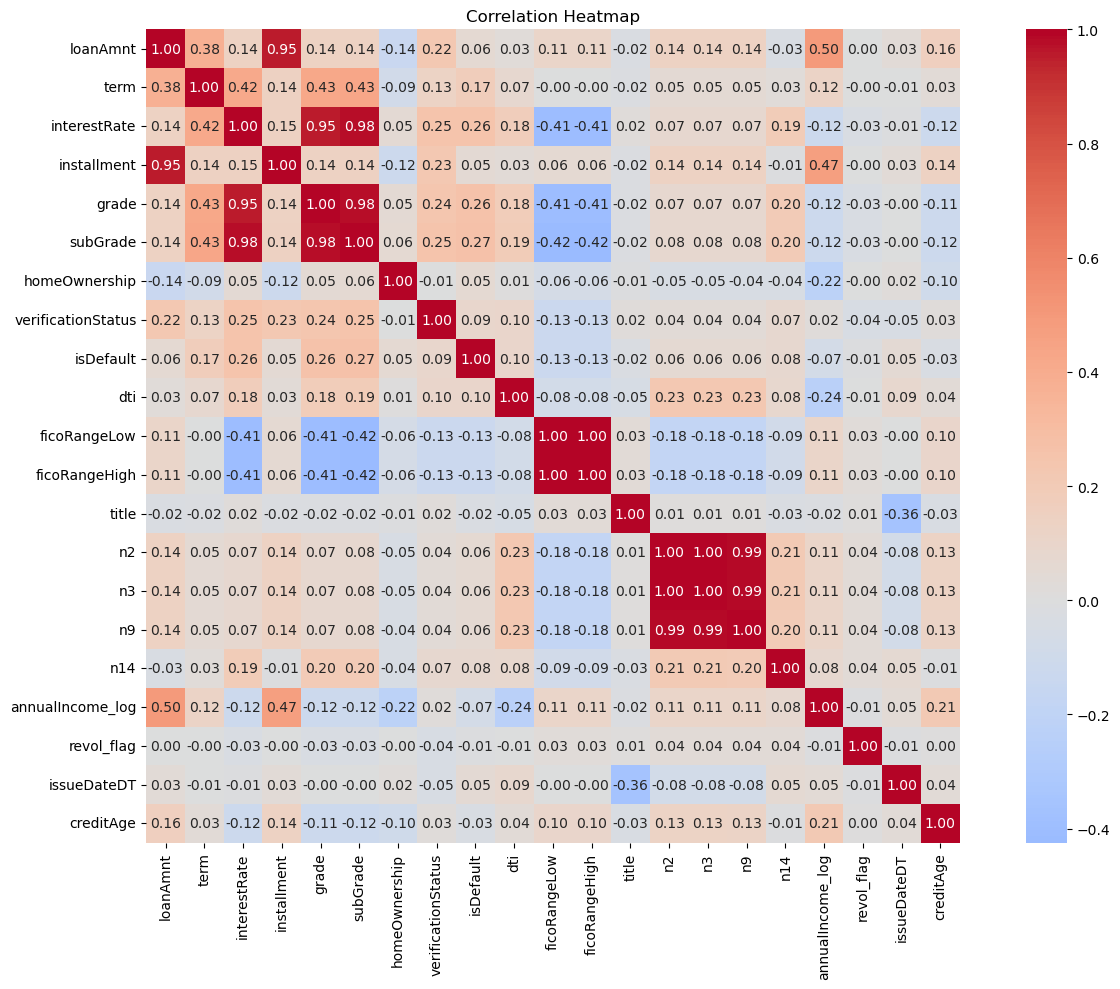

In [192]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 计算相关系数矩阵
corr_matrix = df.corr(numeric_only=True)

# 画图
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,          # 显示相关系数
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()

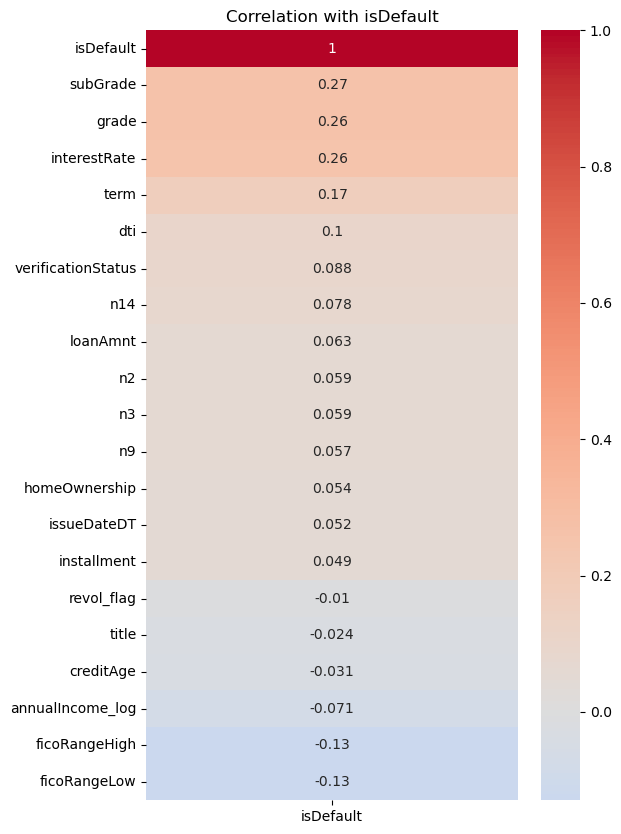

In [194]:
corr_target = (
    df.corr(numeric_only=True)
      [['isDefault']]
      .sort_values(
          by='isDefault',
          ascending=False
      )
)

plt.figure(figsize=(6,10))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation with isDefault')

plt.show()

In [196]:
# 保存当前数据集
df.to_csv(
    'model.csv',
    index=False,
    encoding='utf-8-sig'
)

print("保存成功：model.csv")
print("数据维度：", df.shape)

保存成功：model.csv
数据维度： (511886, 21)


In [198]:
# 保留指定变量

logic_cols = [
    'loanAmnt',
    'term',
    'subGrade',
    'homeOwnership',
    'verificationStatus',
    'dti',
    'ficoRangeLow',
    'title',
    'n2',
    'n14',
    'annualIncome_log',
    'revol_flag',
    'issueDateDT',
    'creditAge',
    'isDefault'
]

# 提取数据集
logic_df = df[logic_cols].copy()

# 查看结果
print("数据维度：", logic_df.shape)

print("\n变量列表：")
print(logic_df.columns.tolist())

print("\n前5行数据：")
print(logic_df.head())

# 保存CSV
logic_df.to_csv(
    'logic.csv',
    index=False,
    encoding='utf-8-sig'
)

print("\nlogic.csv 保存成功！")

数据维度： (511886, 15)

变量列表：
['loanAmnt', 'term', 'subGrade', 'homeOwnership', 'verificationStatus', 'dti', 'ficoRangeLow', 'title', 'n2', 'n14', 'annualIncome_log', 'revol_flag', 'issueDateDT', 'creditAge', 'isDefault']

前5行数据：
   loanAmnt  term  subGrade  homeOwnership  verificationStatus    dti  \
0   35000.0     5        21              2                   2  17.05   
1   18000.0     5        16              0                   2  27.83   
2   12000.0     5        17              0                   2  22.77   
3   11000.0     3         3              1                   1  17.21   
4    3000.0     3        11              1                   2  32.16   

   ficoRangeLow   title        n2       n14  annualIncome_log  revol_flag  \
0         730.0     1.0  2.000000  2.000000         11.608245           1   
1         700.0  1723.0  5.646404  2.178891         10.736418           1   
2         675.0     0.0  3.000000  4.000000         11.211834           1   
3         685.0     4.0  6.